In [1]:
from ml_enhance import plot_FI, load_hpc_result, compare
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any
import pandas as pd
import numpy as np
import pickle
import json

## Huber Regression: Topology VS. QM + Topology

As the data (even after transformation and scaling) consists of a lot of outliers that cannot be removed (as they are valid molecules and are therefore part of the real world observables) I decided to use [Huber regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html) instead of linear regression, this method is more robust to outliers.

In [2]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [3]:
def get_coef(estimator) -> np.ndarray:
    return estimator.named_steps['predict'].coef_

In [4]:
BASE = Path("../data/HuberReg_results")

combo_df = load_hpc_result(BASE / "HuberReg_combo_results.pkl", "topo+QM")
combo_filtered_df = load_hpc_result(BASE / "HuberReg_combo_filtered_results.pkl", "topo+QM_filtered")
topo_filtered_df = load_hpc_result(BASE / "HuberReg_topo_filtered_results.pkl", "topo_filtered")
qm_filtered_df = load_hpc_result(BASE / "HuberReg_qm_filtered_results.pkl", "qm_filtered")

# topo_df = load_hpc_result(BASE / "HuberReg_topo.pkl", "topo")
# qm_df = load_hpc_result(BASE / "HuberReg_qm2.pkl", "qm")

In [5]:
n_tot = df.shape[0]
n_train = n_tot * 4 // 5  
n_test = n_tot - n_train
n_tot

8763

array([  9,  11,  12,  13,  14,  17,  19,  20,  28,  34,  52,  53,  64,
        65,  66,  69,  90,  92,  98,  99, 100, 106, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 125, 126, 127, 130, 133, 191, 193, 204,
       213, 216, 219, 226, 238, 244, 251, 281, 282, 284])

In [30]:
test = combo_filtered_df.estimator[0].best_estimator_[0].get_feature_names_out()
to_drop = combo_filtered_df.estimator[0].best_estimator_[1].to_drop_
test[to_drop]
test[combo_filtered_df.estimator[0].best_estimator_[1].get_feature_names_out()]

array(['atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_polarizability_mean',
       'molecular_polarizability_anisotropy', 'solvation_energy_water',
       'delta_gibbs_free_energy_300K', 'gibbs_free_energy_300K_range',
       'delta_enthalpy', 'delta_entropy_300K', 'entropy_300K_range',
       'std_entropy_300K', 'delta_heat_capacity_300K',
       'heat_capacity_300K_range', 'std_heat_capacity_300K', 'rigid_flag',
       'ir_centroid_freq_1500', 'ir_norm_intensity_1500',
       'ir_mode_count_1500_2750', 'ir_centroid_freq_1500_2750',
       'ir_norm_intensity_1500_2750', 'ir_centroid_freq_2750_4000',
       'ir_norm_intensity_2750_4000', 'avg_atomic_dipole_norm',
       'min_atomic_dipole_norm', 'max_atomic_dipole_norm',
       'std_atomic_dipole_norm',
       'avg_atomic_quadrupole_principal_invariant_2',
       'min_atomic_quad

In [6]:
from ml_enhance import compare

# print("combo VS topo")
# compare(combo_df, topo_df, qm_df, n_tot)
# print("\n\n")
print("combo_filtered VS topo_filtered")
compare(combo_filtered_df, topo_filtered_df, qm_filtered_df, n_tot)

combo_filtered VS topo_filtered
topo+QM_filtered mean r2: 0.8223499477581054 (Train: 0.841476248959554)
topo_filtered mean r2: 0.8160230235179149 (Train: 0.8279642830649816)
qm_filtered mean r2: 0.7411990465587013 (Train: 0.7582517461419046)
Mean improvement: 0.0063269242401905726
T-test p-value: 0.1215621705388823 -> not statistically significant
Wilcoxon p-value: 7.49826431274414e-05 -> statistically significant


topo+QM_filtered mean MSE: 0.9456045108486053 (Train: 0.8442863222843465)
topo_filtered mean MSE: 0.9789233945696367 (Train: 0.9162571140908023)
qm_filtered mean MSE: 1.3771484487831915 (Train: 1.287544430222358)
Mean improvement: -0.03331888372103153
T-test p-value: 0.13048720787473833 -> not statistically significant
Wilcoxon p-value: 7.49826431274414e-05 -> statistically significant




In [7]:
r2_df = pd.concat([df[["name", "test_r2"]] for df in [combo_df, combo_filtered_df, topo_filtered_df]])

C:\Users\thibo\AppData\Local\Temp\ipykernel_26560\553325310.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


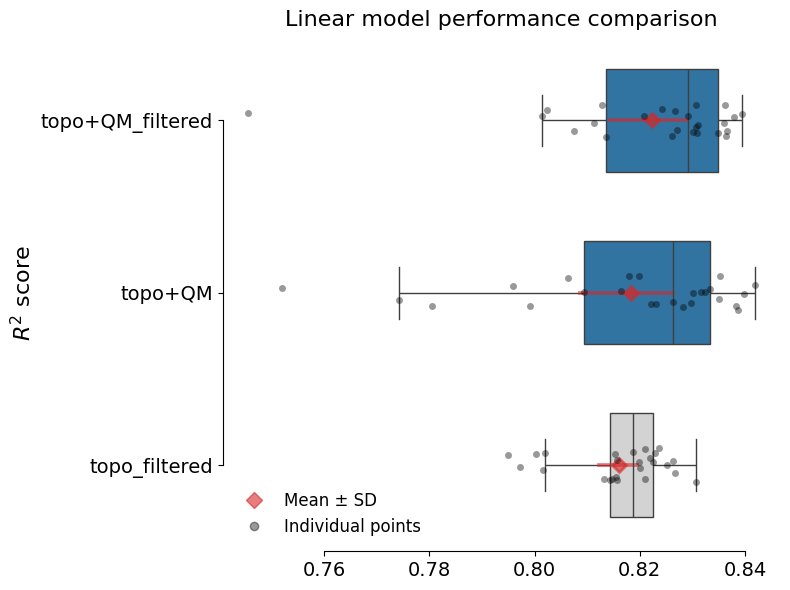

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

order = (
    r2_df.groupby("name")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# blue_models = ["topo+QM", "topo+QM_rfe", "topo+QM_filtered", "topo+QM_filtered_rfe"]

palette = {
    model: "tab:blue" if 'QM' in model else "lightgray"
    for model in r2_df["name"].unique()
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df,
    y="name",
    x="test_r2",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df,
    y="name",
    x="test_r2",
    order=order,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df, y="name", x="test_r2", color="black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    # Patch(facecolor="tab:blue", edgecolor="black", label="QM + topo"),
    # Patch(facecolor="lightgray", edgecolor="black", label="Topo-only"),
    Patch(facecolor="tab:red", edgecolor="black", label="Mean ± SD"),
    Patch(facecolor="black", edgecolor="black", label="Individual points", alpha=0.4)
]

sns.despine(trim=True, left=False)

plt.legend(handles=[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Linear model performance comparison", fontsize=16)
# plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

Based on the results i got from the Huber regression, the QM descriptors alone seem to give the worst performance out of the three and **there seems to be no significant difference between the topological descriptors alone and the combined feature set**. 

<!-- The combined set of features provides a slightly better prediction. Whether this is truely because of the QM descriptors, or because of model bias should be analyzed by looking at other models (RF, GAM, KRR?) -->

In [9]:
from collections import Counter

all_params = [estimator.best_params_ for estimator in combo_df["estimator"]]

count = Counter(tuple(p.items()) for p in all_params)
most_common = count.most_common(1)
best_params = dict(most_common[0][0])
best_params

{'predict__alpha': 0.01, 'predict__epsilon': 2.0}

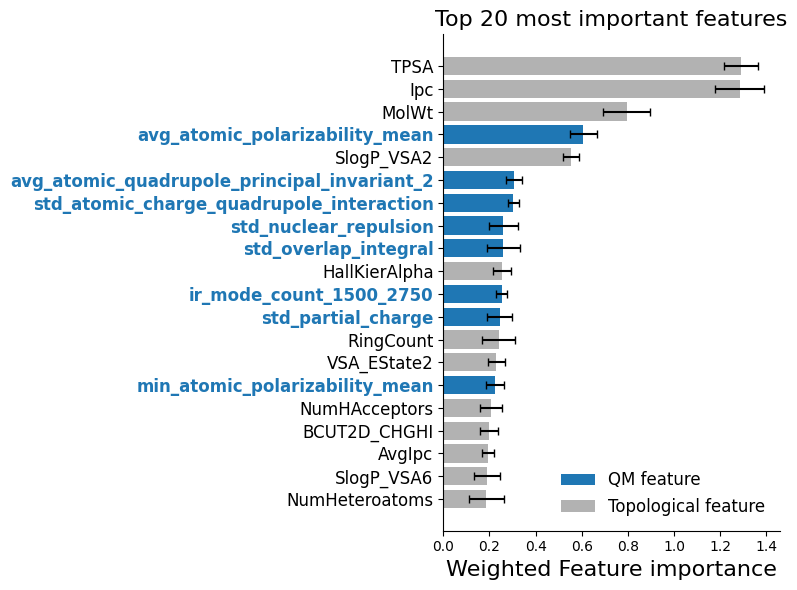

In [10]:
from ml_enhance import FeatureImportance

FI = FeatureImportance(combo_filtered_df)
fi_df = FI.get_feature_importance(mode="full", weight_by_score=True)
FI.plot(20)

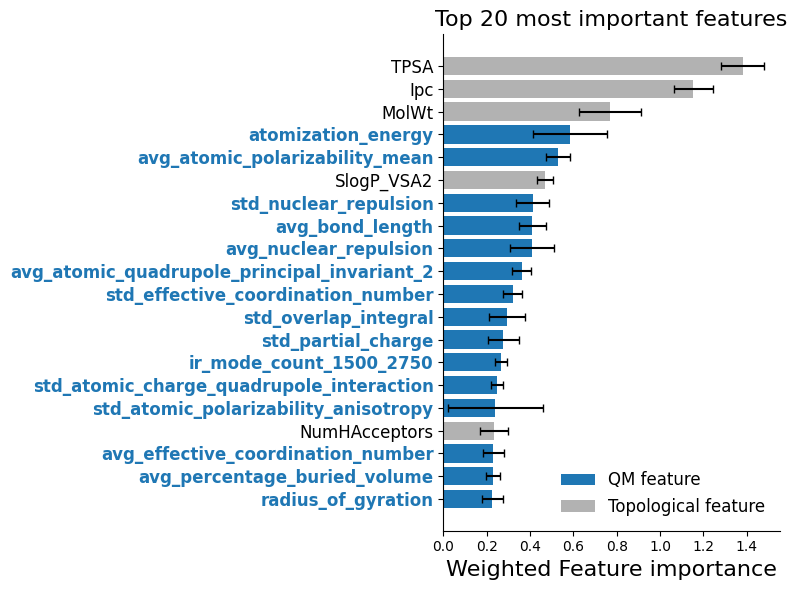

In [11]:
FI = FeatureImportance(combo_df)
fi_df = FI.get_feature_importance(mode="full", weight_by_score=True)
FI.plot(20)

So, after removing the topological features from the QFP feature set, it seems like a lot of QM features have gained more importance for the Topology + QM feature set